# Sprint 2 - Modelizacion y Politica de Rotacion Agrovoltaica

## Objetivo del sprint
Desarrollar un pipeline de modelizacion que permita proponer una politica operativa de rotacion de placas compatible con un objetivo multiobjetivo Energia-Cultivo.

## Alcance de este notebook
Este entregable cubre la parte tecnica del Sprint 2:
- `S2-01` Definicion del target y de las features
- `S2-02` Preparacion y limpieza del dataset de modelizacion
- `S2-03` Entrenamiento y evaluacion de dos enfoques
- `S2-04` Traduccion a reglas interpretables
- `S2-05` Publicacion del codigo del modelo en formato notebook

## Criterio de trabajo
- Se mantiene la misma estructura de entrega que en Sprint 1: un unico notebook.
- Se corrige el pipeline de limpieza para que funcione con versiones recientes de `pandas`, donde varias columnas llegan como dtype `string`.
- La validacion tecnica y agronomica final sigue pendiente del equipo de planta y del especialista agricola.


---

## 1. Setup y supuestos

Supuestos explicitos de este sprint:
- Se trabaja con la carpeta `data/` del repositorio.
- Se reutiliza la granularidad de 6 horas del Sprint 1 para maximizar solapamiento temporal.
- El indice combinado `IEC` se formula aqui como **propuesta operativa provisional**, pendiente de validacion con el equipo.
- El angulo solar teorico se calcula con una aproximacion astronomica usando latitud `41.39N` como proxy de la localizacion de la planta. Este punto debe confirmarse con el equipo tecnico.


In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from pandas.api.types import is_object_dtype, is_string_dtype
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

NOTEBOOK_DIR = Path(os.getcwd())
DATA_DIR = NOTEBOOK_DIR.parent / "data"
OUT_DIR = NOTEBOOK_DIR / "outputs"
OUT_DIR.mkdir(exist_ok=True)

print(f"DATA_DIR: {DATA_DIR}")
print(f"OUT_DIR : {OUT_DIR}")
print(f"pandas  : {pd.__version__}")


DATA_DIR: /Users/joelalfaro/Documents/UPC/Q6/PIA/PIA_lab-main/data
OUT_DIR : /Users/joelalfaro/Documents/UPC/Q6/PIA/PIA_lab-main/sprint2/outputs
pandas  : 3.0.2


## 2. Pipeline de limpieza y carga

En lugar de separar un modulo externo, se formalizan aqui las funciones pedidas para el sprint manteniendo el formato de entrega del Sprint 1:
- `strip_unit`
- `load_csv`
- `resample_to_6h`

La mejora clave respecto al Sprint 1 es que `strip_unit` ya no depende solo de `dtype == object`, sino que tambien soporta columnas `string`.


In [2]:
def strip_unit(series: pd.Series) -> pd.Series:
    """Extrae el valor numerico de columnas string con unidades embebidas."""
    if is_object_dtype(series) or is_string_dtype(series):
        cleaned = series.astype("string").str.extract(r"([\-\d\.]+)", expand=False)
        return pd.to_numeric(cleaned, errors="coerce")
    return series


def detect_sep_line(filepath: Path) -> int:
    """Devuelve 1 si el CSV trae una primera linea tipo sep=, si no 0."""
    with open(filepath, "r", encoding="utf-8-sig") as f:
        first = f.readline().strip()
    return 1 if first.lower().startswith("sep=") else 0


def load_csv(filepath: Path, nrows: int | None = None) -> pd.DataFrame:
    """Carga un CSV corrigiendo BOM UTF-8 y lineas auxiliares sep=."""
    skip = detect_sep_line(filepath)
    df = pd.read_csv(
        filepath,
        skiprows=skip,
        encoding="utf-8-sig",
        nrows=nrows,
        low_memory=False,
    )
    time_cols = [c for c in df.columns if c.strip().lower() == "time"]
    if time_cols:
        df = df.rename(columns={time_cols[0]: "Time"})
        df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
    return df


def strip_all_units(df: pd.DataFrame) -> pd.DataFrame:
    """Aplica strip_unit a todas las columnas salvo Time."""
    out = df.copy()
    for col in out.columns:
        if col != "Time":
            out[col] = strip_unit(out[col])
    return out


def resample_to_6h(df_num: pd.DataFrame, agg: str = "mean") -> pd.DataFrame:
    """Reagrega un dataframe numerico al grid temporal de 6 horas."""
    if "Time" not in df_num.columns:
        raise ValueError("El dataframe debe incluir la columna Time.")
    df_idx = df_num.set_index("Time").sort_index()
    num_cols = df_idx.select_dtypes(include="number").columns.tolist()
    if not num_cols:
        return pd.DataFrame(index=df_idx.index.unique().sort_values())
    return getattr(df_idx[num_cols].resample("6h"), agg)()


DATASETS = {
    "air_temp": "AIR_AIR Temperatures (ALL)-data-as-joinbyfield-2026-02-12 08_56_48.csv",
    "epar": "AIR_ePAR (all parameters)-data-as-joinbyfield-2026-02-12 09_00_37.csv",
    "irradiance": "PV_Irradiance-data-as-joinbyfield-2026-02-12 14_17_50.csv",
    "pv_temp": "PV_PV panel temperatures-data-as-joinbyfield-2026-02-12 14_18_22.csv",
    "soil_temp": "SOIL_Temperature-data-as-joinbyfield-2026-02-12 08_54_57.csv",
    "soil_vwc": "SOIL_VWC-data-as-joinbyfield-2026-02-12 08_57_18.csv",
    "tracking": "Tracking angles-data-as-joinbyfield-2026-02-12 14_24_26.csv",
    "wind_speed": "Wind speed-data-2026-02-12 09_05_40.csv",
}

SELECTED_COLS = {
    "tracking": {
        "tracker_M01 (actual)": "track_M01",
        "tracker_M03 (actual)": "track_M03",
        "tracker_M05 (actual)": "track_M05",
        "tracker_M07 (actual)": "track_M07",
        "tracker_M09 (actual)": "track_M09",
    },
    "irradiance": {
        "S1d12_Z8AI.pyra.GPOA.Wm2": "GPOA_S1",
        "S1d12_Z8AI.pyra.ALBEDO.Wm2": "Albedo_S1",
        "S2d30_Z8AI.pyra.GPOA.Wm2": "GPOA_S2",
        "S2d30_Z8AI.pyra.ALBEDO.Wm2": "Albedo_S2",
    },
    "pv_temp": {
        "S1 T1": "Tpanel_S1T1",
        "S1 T2": "Tpanel_S1T2",
        "S2 T1": "Tpanel_S2T1",
        "S2 T2": "Tpanel_S2T2",
    },
    "air_temp": {
        "WS100.Air.TempAvg.degC": "Tair_WS",
        "S1d10_Z8AI.air.T__center.degC": "Tair_S1_center",
        "S1d10_Z8AI.air.T__east.degC": "Tair_S1_east",
        "S2d30_Z8AI.air.T__east.degC": "Tair_S2_east",
    },
    "soil_temp": {
        "S1d13_HD3910": "Tsoil_S1d13",
        "S1d14_HD3910": "Tsoil_S1d14",
        "S2d32_HD3910": "Tsoil_S2d32",
        "S2d33_HD3910": "Tsoil_S2d33",
    },
    "soil_vwc": {
        "S1d13_HD3910": "VWC_S1d13",
        "S1d14_HD3910": "VWC_S1d14",
        "S2d32_HD3910": "VWC_S2d32",
        "S2d33_HD3910": "VWC_S2d33",
    },
    "epar": {
        "S1d19_SQ618 cal_out": "ePAR_S1d19",
        "S1d20_SQ618 cal_out": "ePAR_S1d20",
        "S2d36_SQ618 cal_out": "ePAR_S2d36",
        "S2d37_SQ618 cal_out": "ePAR_S2d37",
    },
    "wind_speed": {
        "R1d40_Z8AI.air.WS.kmh": "wind_speed_kmh",
    },
}

dfs_raw = {}
dfs_num = {}
for key, fname in DATASETS.items():
    df_raw = load_csv(DATA_DIR / fname)
    dfs_raw[key] = df_raw
    dfs_num[key] = strip_all_units(df_raw)
    print(f"[OK] {key:12s} -> {df_raw.shape[0]:>5} filas x {df_raw.shape[1]} columnas")


[OK] air_temp     ->  1461 filas x 13 columnas
[OK] epar         ->  1461 filas x 25 columnas
[OK] irradiance   ->  1753 filas x 5 columnas
[OK] pv_temp      ->  1753 filas x 9 columnas
[OK] soil_temp    ->  1461 filas x 15 columnas
[OK] soil_vwc     ->  1461 filas x 15 columnas
[OK] tracking     ->  1461 filas x 11 columnas
[OK] wind_speed   ->  1461 filas x 2 columnas


## 3. Validacion tecnica preliminar de trackers

Antes de modelizar conviene revisar el comportamiento de todos los trackers. En Sprint 1 se detectaron posibles trackers atascados (`M02`, `M06`, `M10`); aqui lo dejamos cuantificado para facilitar la validacion con planta.


,varianza_deg2,posible_stow_fijo
tracker_M04 (actual),365.970,False
tracker_M01 (actual),366.087,False
tracker_M03 (actual),366.199,False
tracker_M09 (actual),366.282,False
tracker_M08 (actual),366.362,False
tracker_M02 (actual),508.517,False
tracker_M10 (actual),508.985,False
tracker_M06 (actual),513.013,False
tracker_M05 (actual),534.870,False
tracker_M07 (actual),534.997,False


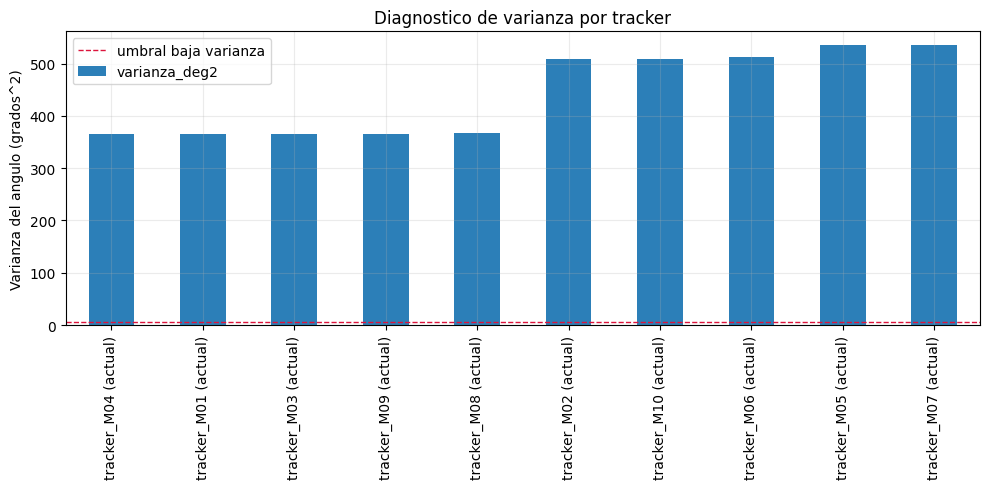

In [3]:
tracking_full = dfs_num["tracking"].copy()
tracker_cols_all = [c for c in tracking_full.columns if c != "Time"]

tracker_var = (
    tracking_full[tracker_cols_all]
    .var()
    .sort_values()
    .rename("varianza_deg2")
    .to_frame()
)
tracker_var["posible_stow_fijo"] = tracker_var["varianza_deg2"] < 5
display(tracker_var)
tracker_var.to_csv(OUT_DIR / "tracker_variance_diagnostic.csv")

fig, ax = plt.subplots(figsize=(10, 5))
tracker_var["varianza_deg2"].plot(kind="bar", ax=ax, color="#2c7fb8")
ax.axhline(5, color="crimson", linestyle="--", linewidth=1, label="umbral baja varianza")
ax.set_title("Diagnostico de varianza por tracker")
ax.set_ylabel("Varianza del angulo (grados^2)")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "tracker_variance_diagnostic.png", dpi=130, bbox_inches="tight")
plt.show()


## 4. Construccion del dataset integrado a 6 horas

Para modelizacion se usa el periodo de solapamiento entre sensores relevantes. Se mantiene el grid temporal de 6 horas del Sprint 1 y se descartan variables no esenciales o con semantica dudosa para esta iteracion.


Dataset integrado: 1462 filas x 30 variables
Periodo: 2025-02-12 06:00:00 -> 2026-02-12 12:00:00
Nulos promedio: 45.9%


,cobertura_pct
Tpanel_S1T1,28.500
Tpanel_S2T2,28.500
Tpanel_S2T1,28.500
Tpanel_S1T2,28.500
Albedo_S2,28.500
GPOA_S1,28.500
Albedo_S1,28.500
GPOA_S2,28.500
wind_speed_kmh,54.500
VWC_S2d32,58.800


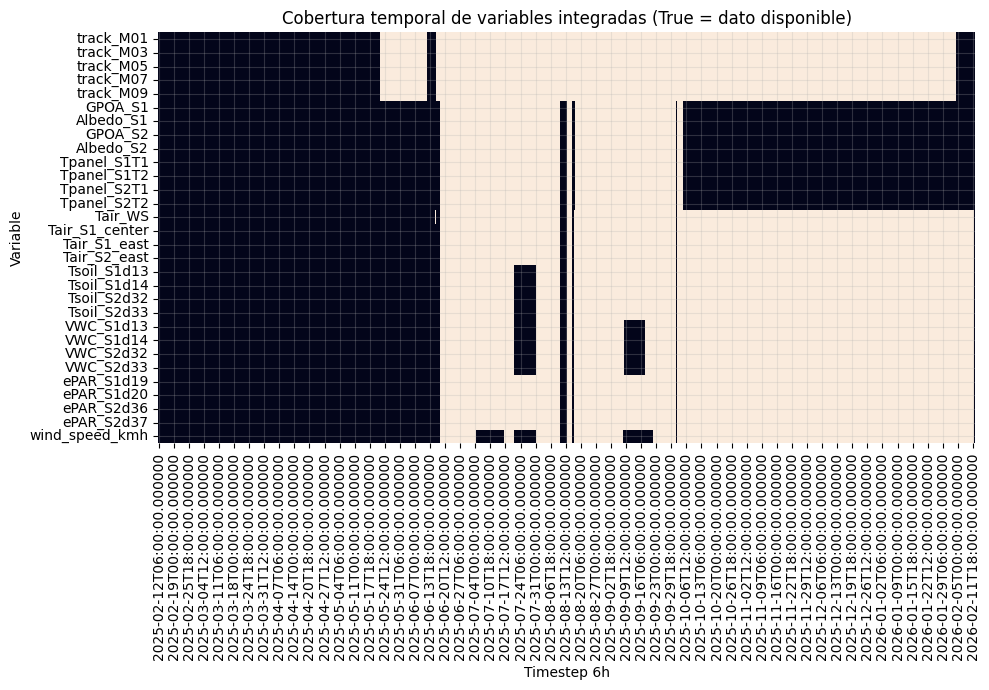

In [4]:
merged_parts = []
for ds_name, col_map in SELECTED_COLS.items():
    df_res = resample_to_6h(dfs_num[ds_name])
    valid = {k: v for k, v in col_map.items() if k in df_res.columns}
    if valid:
        part = df_res[list(valid.keys())].rename(columns=valid)
        merged_parts.append(part)

df_merged = pd.concat(merged_parts, axis=1).sort_index()
coverage = (
    df_merged.notna()
    .mean()
    .sort_values()
    .mul(100)
    .round(1)
    .rename("cobertura_pct")
    .to_frame()
)

print(f"Dataset integrado: {df_merged.shape[0]} filas x {df_merged.shape[1]} variables")
print(f"Periodo: {df_merged.index.min()} -> {df_merged.index.max()}")
print(f"Nulos promedio: {df_merged.isnull().mean().mean() * 100:.1f}%")
display(coverage)

df_merged.to_csv(OUT_DIR / "dataset_integrado_6h.csv")
coverage.to_csv(OUT_DIR / "dataset_integrado_cobertura.csv")

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(df_merged.notna().T, cbar=False, ax=ax)
ax.set_title("Cobertura temporal de variables integradas (True = dato disponible)")
ax.set_xlabel("Timestep 6h")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.savefig(OUT_DIR / "dataset_integrado_cobertura.png", dpi=130, bbox_inches="tight")
plt.show()


## 5. Feature engineering

Features incorporadas en este sprint:
- `hour_of_day`
- `day_of_year`
- `solar_elevation_deg`
- `Tsoil_*_mean`
- `Tsoil_S1_mean_lag_6h`, `Tsoil_S1_mean_lag_12h`
- `VWC_diff_S1_minus_S2`
- `tracking_regime`
- agregados medios por seccion (`ePAR`, `VWC`, `Tsoil`, tracking)


In [5]:
lat_rad = np.deg2rad(41.39)  # proxy pendiente de confirmar con planta
day_of_year = df_merged.index.dayofyear.to_numpy()
hour_of_day = df_merged.index.hour.to_numpy()
declination = np.deg2rad(23.44) * np.sin(2 * np.pi * (284 + day_of_year) / 365)
hour_angle = np.deg2rad(15 * (hour_of_day - 12))
solar_elevation = np.arcsin(
    np.sin(lat_rad) * np.sin(declination)
    + np.cos(lat_rad) * np.cos(declination) * np.cos(hour_angle)
)

df_feat = df_merged.copy()
df_feat["hour_of_day"] = df_feat.index.hour
df_feat["day_of_year"] = df_feat.index.dayofyear
df_feat["solar_elevation_deg"] = np.degrees(solar_elevation).clip(min=0)

df_feat["Tsoil_S1_mean"] = df_feat[["Tsoil_S1d13", "Tsoil_S1d14"]].mean(axis=1)
df_feat["Tsoil_S2_mean"] = df_feat[["Tsoil_S2d32", "Tsoil_S2d33"]].mean(axis=1)
df_feat["VWC_S1_mean"] = df_feat[["VWC_S1d13", "VWC_S1d14"]].mean(axis=1)
df_feat["VWC_S2_mean"] = df_feat[["VWC_S2d32", "VWC_S2d33"]].mean(axis=1)
df_feat["ePAR_S1_mean"] = df_feat[["ePAR_S1d19", "ePAR_S1d20"]].mean(axis=1)
df_feat["ePAR_S2_mean"] = df_feat[["ePAR_S2d36", "ePAR_S2d37"]].mean(axis=1)
df_feat["track_mean"] = df_feat[["track_M01", "track_M03", "track_M05", "track_M07", "track_M09"]].mean(axis=1)

for lag in [1, 2]:
    df_feat[f"Tsoil_S1_mean_lag_{lag * 6}h"] = df_feat["Tsoil_S1_mean"].shift(lag)

df_feat["VWC_diff_S1_minus_S2"] = df_feat["VWC_S1_mean"] - df_feat["VWC_S2_mean"]

def classify_regime(angle: float) -> str:
    if pd.isna(angle):
        return "UNKNOWN"
    if abs(angle - 50.6) < 0.75:
        return "STOW"
    if abs(angle) < 5:
        return "HORIZONTAL"
    return "TRACKING_AM" if angle < 0 else "TRACKING_PM"

df_feat["tracking_regime"] = df_feat["track_mean"].apply(classify_regime)

feature_snapshot = df_feat[[
    "hour_of_day",
    "day_of_year",
    "solar_elevation_deg",
    "track_mean",
    "tracking_regime",
    "Tsoil_S1_mean",
    "Tsoil_S1_mean_lag_6h",
    "Tsoil_S1_mean_lag_12h",
    "VWC_diff_S1_minus_S2",
    "ePAR_S1_mean",
    "ePAR_S2_mean",
]].head(10)

display(feature_snapshot)


,hour_of_day,day_of_year,solar_elevation_deg,track_mean,tracking_regime,Tsoil_S1_mean,Tsoil_S1_mean_lag_6h,Tsoil_S1_mean_lag_12h,VWC_diff_S1_minus_S2,ePAR_S1_mean,ePAR_S2_mean
Time,,,,,,,,,,,
2025-02-12 06:00:00,6,43,0.000,<NA>,UNKNOWN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2025-02-12 12:00:00,12,43,34.347,<NA>,UNKNOWN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2025-02-12 18:00:00,18,43,0.000,<NA>,UNKNOWN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2025-02-13 00:00:00,0,44,0.000,<NA>,UNKNOWN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2025-02-13 06:00:00,6,44,0.000,<NA>,UNKNOWN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2025-02-13 12:00:00,12,44,34.670,<NA>,UNKNOWN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2025-02-13 18:00:00,18,44,0.000,<NA>,UNKNOWN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2025-02-14 00:00:00,0,45,0.000,<NA>,UNKNOWN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2025-02-14 06:00:00,6,45,0.000,<NA>,UNKNOWN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


## 6. Definicion provisional del target: Indice Energia-Cultivo (IEC)

Dado que no existe aun un target validado por el equipo, se propone una formulacion interpretable y explicitamente provisional:

- `energy_score`: proxy energetico a partir de la media `GPOA_S1` y `GPOA_S2`, normalizada por el percentil 95.
- `crop_score`: combinacion ponderada de tres proxys agronomicos:
  - `ePAR` medio centrado en 600 umol/m2/s
  - `VWC` medio centrado en 30%
  - `Tsoil` medio centrado en 28 C
- `IEC = 0.5 * energy_score + 0.5 * crop_score`

Esta formulacion sirve para el Sprint 2 como objetivo de trabajo del modelo, pero debe revisarse con:
- tipo real de cultivo
- umbrales agronomicos validos
- politica de pesos definitiva energia vs cultivo


,energy_score,crop_score,IEC
count,416.000,860.000,337.000
mean,0.339,0.392,0.397
std,0.349,0.165,0.248
min,0.000,0.112,0.063
25%,0.000,0.251,0.183
50%,0.225,0.378,0.360
75%,0.599,0.517,0.598
max,1.000,0.940,0.925


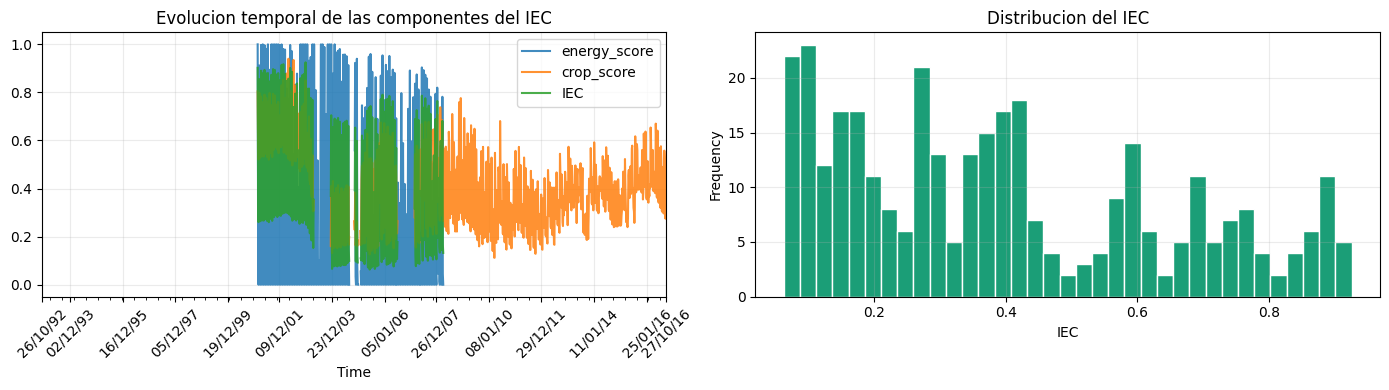

In [6]:
df_model_base = df_feat.copy()

df_model_base["energy_proxy"] = df_model_base[["GPOA_S1", "GPOA_S2"]].mean(axis=1).clip(lower=0)
energy_p95 = df_model_base["energy_proxy"].quantile(0.95)
df_model_base["energy_score"] = (df_model_base["energy_proxy"] / energy_p95).clip(0, 1)

epar_mean = df_model_base[["ePAR_S1_mean", "ePAR_S2_mean"]].mean(axis=1)
vwc_mean = df_model_base[["VWC_S1_mean", "VWC_S2_mean"]].mean(axis=1)
tsoil_mean = df_model_base[["Tsoil_S1_mean", "Tsoil_S2_mean"]].mean(axis=1)

par_score = (1 - ((epar_mean - 600).abs() / 600)).clip(0, 1)
vwc_score = (1 - ((vwc_mean - 30).abs() / 15)).clip(0, 1)
tsoil_score = (1 - ((tsoil_mean - 28).abs() / 10)).clip(0, 1)

df_model_base["crop_score"] = 0.4 * par_score + 0.4 * vwc_score + 0.2 * tsoil_score
df_model_base["IEC"] = 0.5 * df_model_base["energy_score"] + 0.5 * df_model_base["crop_score"]

iec_summary = df_model_base[["energy_score", "crop_score", "IEC"]].describe().round(3)
display(iec_summary)
iec_summary.to_csv(OUT_DIR / "iec_summary.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_model_base[["energy_score", "crop_score", "IEC"]].plot(ax=axes[0], alpha=0.85)
axes[0].set_title("Evolucion temporal de las componentes del IEC")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m/%y"))
axes[0].tick_params(axis="x", rotation=45)

df_model_base["IEC"].dropna().plot(kind="hist", bins=35, ax=axes[1], color="#1b9e77", edgecolor="white")
axes[1].set_title("Distribucion del IEC")
axes[1].set_xlabel("IEC")

plt.tight_layout()
plt.savefig(OUT_DIR / "iec_overview.png", dpi=130, bbox_inches="tight")
plt.show()


## 7. Dataset de modelizacion, train/test split y normalizacion

La ventana de modelizacion se define sobre el periodo de solapamiento util y se conserva una particion temporal `80/20`:
- `train`: primeros 80% de observaciones validas
- `test`: ultimo 20%

Se exige una cobertura minima del `75%` de features por fila para evitar entrenar con registros excesivamente incompletos.


In [7]:
FEATURE_COLS = [
    "hour_of_day",
    "day_of_year",
    "solar_elevation_deg",
    "track_mean",
    "tracking_regime",
    "Tair_WS",
    "Tair_S1_center",
    "wind_speed_kmh",
    "GPOA_S1",
    "GPOA_S2",
    "Albedo_S1",
    "Albedo_S2",
    "Tsoil_S1_mean",
    "Tsoil_S2_mean",
    "Tsoil_S1_mean_lag_6h",
    "Tsoil_S1_mean_lag_12h",
    "VWC_S1_mean",
    "VWC_S2_mean",
    "VWC_diff_S1_minus_S2",
    "ePAR_S1_mean",
    "ePAR_S2_mean",
]

df_model = df_model_base[FEATURE_COLS + ["IEC", "energy_score", "crop_score"]].dropna(subset=["IEC"]).copy()
df_model = df_model[df_model[FEATURE_COLS].notna().mean(axis=1) >= 0.75].copy()

split_idx = int(len(df_model) * 0.8)
train_df = df_model.iloc[:split_idx].copy()
test_df = df_model.iloc[split_idx:].copy()

print(f"Observaciones modelables: {len(df_model)}")
print(f"Periodo util: {df_model.index.min()} -> {df_model.index.max()}")
print(f"Train: {len(train_df)} filas | Test: {len(test_df)} filas")

df_model.to_csv(OUT_DIR / "dataset_modelizacion_6h.csv")

display(
    pd.DataFrame(
        {
            "subset": ["train", "test"],
            "n_filas": [len(train_df), len(test_df)],
            "fecha_ini": [train_df.index.min(), test_df.index.min()],
            "fecha_fin": [train_df.index.max(), test_df.index.max()],
        }
    )
)


Observaciones modelables: 337
Periodo util: 2025-06-18 12:00:00 -> 2025-10-05 00:00:00
Train: 269 filas | Test: 68 filas


,subset,n_filas,fecha_ini,fecha_fin
0,train,269,2025-06-18 12:00:00,2025-09-07 18:00:00
1,test,68,2025-09-08 00:00:00,2025-10-05 00:00:00


## 8. Entrenamiento de modelos

Se prueban dos enfoques complementarios:
- `DecisionTreeRegressor`: interpretable y util para extraer reglas operativas.
- `ElasticNetCV`: regresion regularizada para generalizacion y lectura de pesos.


,modelo,mae,rmse,r2
1,ElasticNet,0.038,0.051,0.948
0,DecisionTree,0.073,0.094,0.828


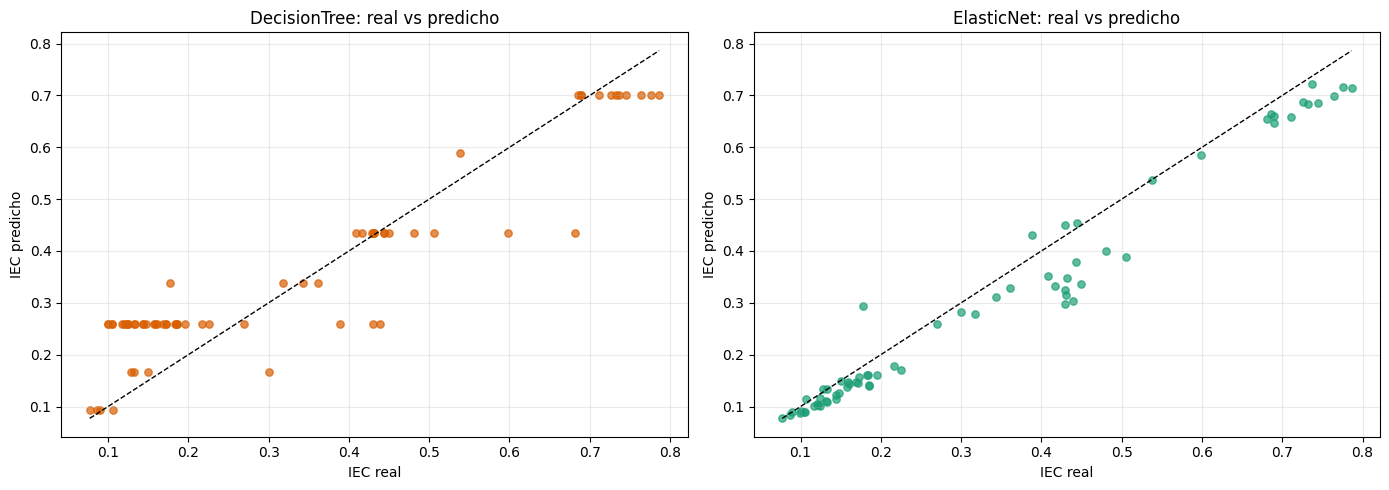

In [8]:
X_train = train_df[FEATURE_COLS]
y_train = train_df["IEC"]
X_test = test_df[FEATURE_COLS]
y_test = test_df["IEC"]

numeric_features = [c for c in FEATURE_COLS if c != "tracking_regime"]
categorical_features = ["tracking_regime"]

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]
            ),
            categorical_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
).set_output(transform="pandas")

elastic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X_train_tree = tree_preprocessor.fit_transform(X_train)
X_test_tree = tree_preprocessor.transform(X_test)

tree_model = DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, random_state=42)
tree_model.fit(X_train_tree, y_train)

elastic_model = Pipeline(
    steps=[
        ("preprocessor", elastic_preprocessor),
        (
            "model",
            ElasticNetCV(
                l1_ratio=[0.1, 0.5, 0.7, 0.9, 1.0],
                alphas=np.logspace(-3, 1, 30),
                cv=5,
                random_state=42,
                max_iter=20000,
            ),
        ),
    ]
)
elastic_model.fit(X_train, y_train)

predictions = {
    "DecisionTree": tree_model.predict(X_test_tree),
    "ElasticNet": elastic_model.predict(X_test),
}

metrics_rows = []
for model_name, y_pred in predictions.items():
    metrics_rows.append(
        {
            "modelo": model_name,
            "mae": mean_absolute_error(y_test, y_pred),
            "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
            "r2": r2_score(y_test, y_pred),
        }
    )

metrics_df = pd.DataFrame(metrics_rows).sort_values("rmse")
display(metrics_df.round(4))
metrics_df.to_csv(OUT_DIR / "model_metrics.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = {"DecisionTree": "#d95f02", "ElasticNet": "#1b9e77"}
for ax, (model_name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, y_pred, alpha=0.7, color=palette[model_name], s=28)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "--", color="black", linewidth=1)
    ax.set_title(f"{model_name}: real vs predicho")
    ax.set_xlabel("IEC real")
    ax.set_ylabel("IEC predicho")

plt.tight_layout()
plt.savefig(OUT_DIR / "model_predictions_vs_actual.png", dpi=130, bbox_inches="tight")
plt.show()


## 9. Interpretabilidad del arbol de decision

El arbol se usa como modelo interpretable para extraer reglas candidatas. No se interpreta como politica final cerrada, sino como base cuantitativa para revision tecnica y agronomica.


|--- Albedo_S1 <= 55.705
|   |--- Albedo_S2 <= 18.015
|   |   |--- VWC_S1_mean <= 22.225
|   |   |   |--- GPOA_S2 <= 35.482
|   |   |   |   |--- value: [0.093]
|   |   |   |--- GPOA_S2 >  35.482
|   |   |   |   |--- value: [0.167]
|   |   |--- VWC_S1_mean >  22.225
|   |   |   |--- Tair_S1_center <= 23.150
|   |   |   |   |--- value: [0.260]
|   |   |   |--- Tair_S1_center >  23.150
|   |   |   |   |--- value: [0.292]
|   |--- Albedo_S2 >  18.015
|   |   |--- VWC_S1_mean <= 19.975
|   |   |   |--- value: [0.339]
|   |   |--- VWC_S1_mean >  19.975
|   |   |   |--- value: [0.435]
|--- Albedo_S1 >  55.705
|   |--- solar_elevation_deg <= 68.005
|   |   |--- GPOA_S1 <= 727.500
|   |   |   |--- value: [0.590]
|   |   |--- GPOA_S1 >  727.500
|   |   |   |--- value: [0.701]
|   |--- solar_elevation_deg >  68.005
|   |   |--- value: [0.862]



,importance
Albedo_S1,0.767
Albedo_S2,0.112
solar_elevation_deg,0.057
VWC_S1_mean,0.048
GPOA_S1,0.010
GPOA_S2,0.005
Tair_S1_center,0.001
hour_of_day,0.000
tracking_regime_TRACKING_AM,0.000
tracking_regime_HORIZONTAL,0.000


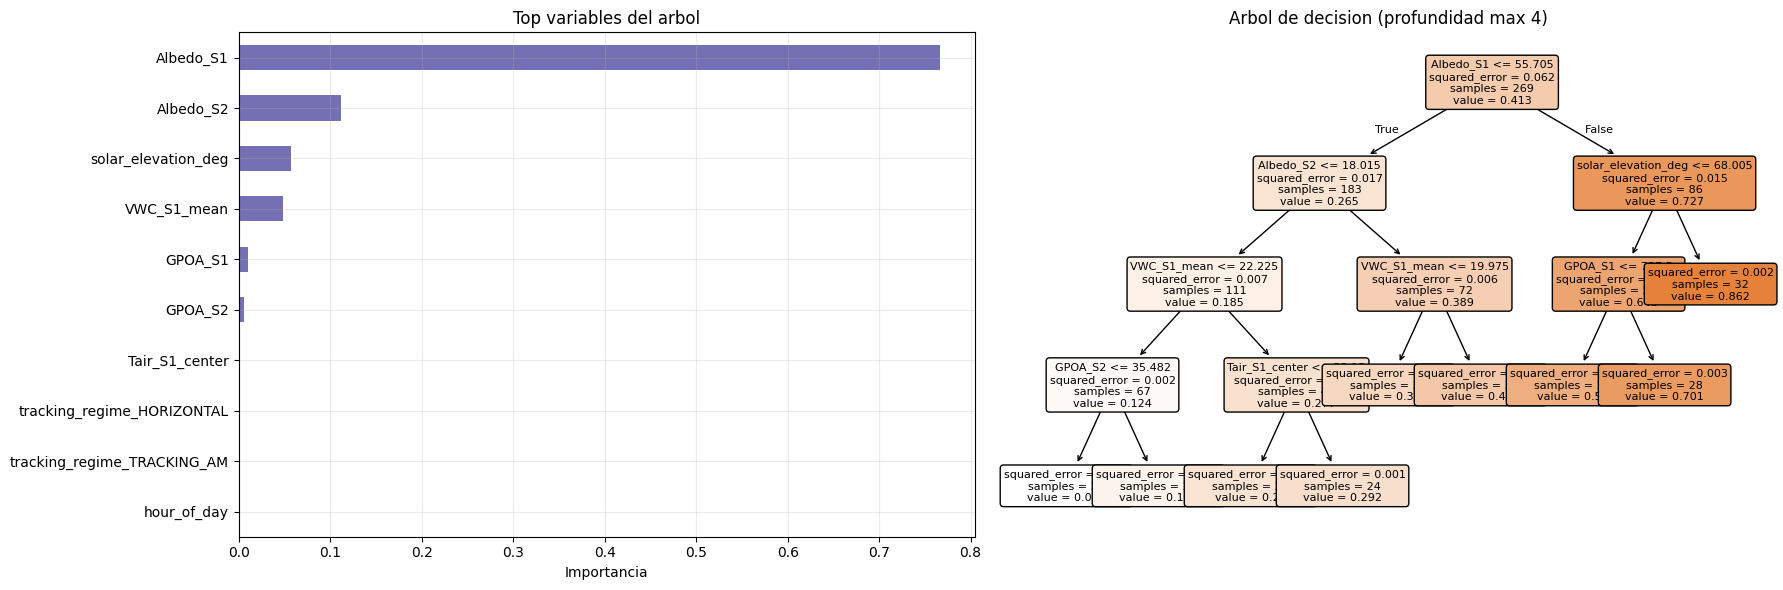

In [9]:
tree_feature_names = list(X_train_tree.columns)
tree_rules_text = export_text(tree_model, feature_names=tree_feature_names, decimals=3)
print(tree_rules_text)

with open(OUT_DIR / "decision_tree_rules.txt", "w", encoding="utf-8") as f:
    f.write(tree_rules_text)

tree_importance = (
    pd.Series(tree_model.feature_importances_, index=tree_feature_names)
    .sort_values(ascending=False)
    .rename("importance")
    .to_frame()
)
display(tree_importance.head(12))
tree_importance.to_csv(OUT_DIR / "decision_tree_feature_importance.csv")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
tree_importance["importance"].head(10).sort_values().plot(kind="barh", ax=axes[0], color="#7570b3")
axes[0].set_title("Top variables del arbol")
axes[0].set_xlabel("Importancia")

plot_tree(
    tree_model,
    feature_names=tree_feature_names,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=axes[1],
)
axes[1].set_title("Arbol de decision (profundidad max 4)")

plt.tight_layout()
plt.savefig(OUT_DIR / "decision_tree_interpretability.png", dpi=130, bbox_inches="tight")
plt.show()


## 10. Interpretabilidad de la regresion regularizada

La regresion regularizada aporta una lectura complementaria:
- signos de efecto
- magnitud relativa de las variables retenidas
- penalizacion de variables redundantes


,coeficiente
tracking_regime_HORIZONTAL,-0.149
GPOA_S1,0.075
GPOA_S2,0.072
tracking_regime_TRACKING_PM,0.064
Tsoil_S2_mean,0.046
VWC_S2_mean,0.041
ePAR_S1_mean,-0.037
Tsoil_S1_mean,-0.030
VWC_S1_mean,0.029
solar_elevation_deg,-0.022


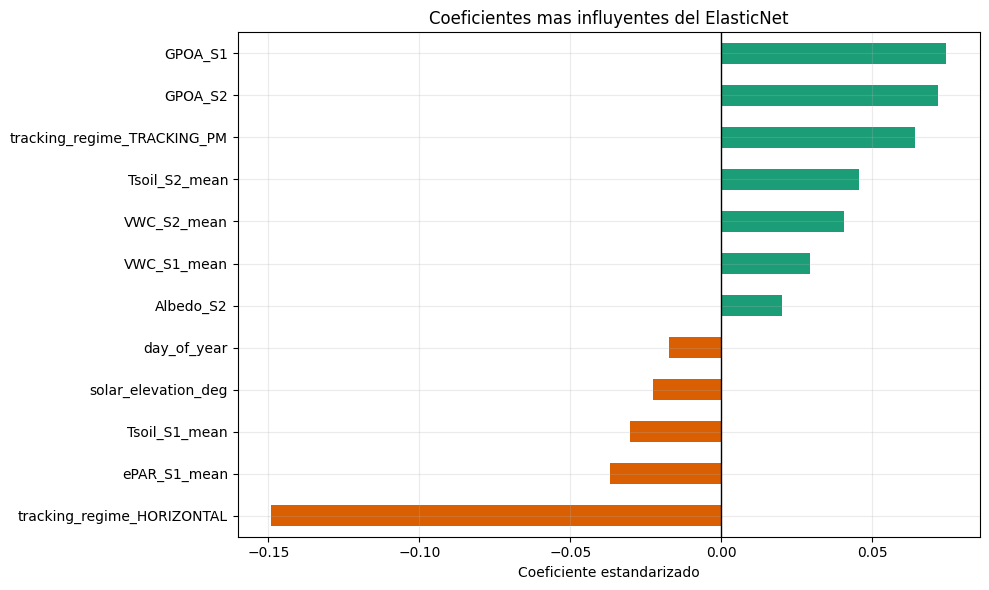

In [10]:
elastic_feature_names = elastic_model.named_steps["preprocessor"].get_feature_names_out()
elastic_coef = pd.Series(
    elastic_model.named_steps["model"].coef_,
    index=elastic_feature_names,
    name="coeficiente",
)
elastic_coef = elastic_coef[elastic_coef.abs() > 1e-6].sort_values(key=lambda s: s.abs(), ascending=False)
display(elastic_coef.head(15).to_frame())
elastic_coef.to_csv(OUT_DIR / "elasticnet_coefficients.csv", header=True)

fig, ax = plt.subplots(figsize=(10, 6))
top_coef = elastic_coef.head(12).sort_values()
colors = ["#d95f02" if v < 0 else "#1b9e77" for v in top_coef]
top_coef.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Coeficientes mas influyentes del ElasticNet")
ax.set_xlabel("Coeficiente estandarizado")
plt.tight_layout()
plt.savefig(OUT_DIR / "elasticnet_coefficients.png", dpi=130, bbox_inches="tight")
plt.show()


## 11. Traduccion a reglas operativas candidatas

Para aterrizar la politica de rotacion se combinan:
- el arbol interpretable
- la comparativa por regimen
- los periodos de `IEC` alto (percentil 75)

La idea no es afirmar una politica definitiva, sino dejar reglas candidatas trazables y revisables.


,count,mean,median
tracking_regime,,,
HORIZONTAL,169,0.204,0.184
TRACKING_AM,84,0.440,0.429
TRACKING_PM,84,0.742,0.741


,hour_of_day,tracking_regime,n_obs,iec_mediana,angle_mediano,solar_mediana,vwc_s1_mediana,vwc_s2_mediana
1,12,TRACKING_PM,75,0.769,31.800,65.432,24.000,20.750
0,6,TRACKING_AM,10,0.602,-32.240,15.216,29.175,31.050


,tipo,regla,soporte_obs,iec_mediana,comentario
0,prioridad_alta,Si Albedo_S1 > 55.7 y la elevacion solar teori...,33,0.862,Regla derivada del nodo de mayor IEC del arbol...
1,operativa,Si la franja es 12:00 y el sistema opera en TR...,75,0.769,Regla derivada del subconjunto de IEC alto obs...
2,operativa,Si la franja es 06:00 y el sistema opera en TR...,10,0.602,Regla derivada del subconjunto de IEC alto obs...
3,transicion,Si Albedo_S1 <= 55.7 pero Albedo_S2 > 18.0 y V...,51,0.435,Nodo intermedio del arbol con rendimiento acep...
4,evitacion,Evitar HORIZONTAL en las franjas productivas c...,169,0.184,IEC medio HORIZONTAL=0.204 frente a TRACKING_P...
5,cautela_hidrica,"Si Albedo_S1 <= 55.7, Albedo_S2 <= 18.0, VWC_S...",43,0.093,Nodo mas desfavorable del arbol; conviene trat...


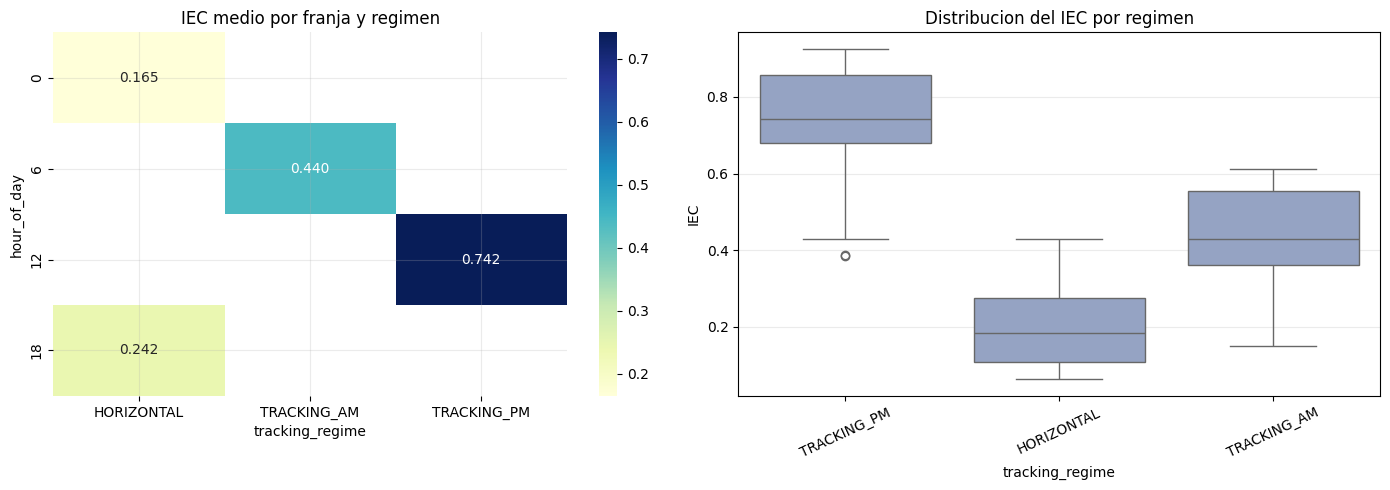

In [11]:
policy_stats = (
    df_model_base[[
        "hour_of_day",
        "tracking_regime",
        "track_mean",
        "IEC",
        "energy_score",
        "crop_score",
        "VWC_S1_mean",
        "VWC_S2_mean",
        "solar_elevation_deg",
    ]]
    .dropna(subset=["IEC"])
)
policy_stats = policy_stats[policy_stats.notna().mean(axis=1) >= 0.75]

regime_summary = policy_stats.groupby("tracking_regime")["IEC"].agg(["count", "mean", "median"]).round(3)
display(regime_summary)
regime_summary.to_csv(OUT_DIR / "regime_summary_iec.csv")

iec_high_threshold = policy_stats["IEC"].quantile(0.75)
high_iec = policy_stats[policy_stats["IEC"] >= iec_high_threshold].copy()

high_iec_table = (
    high_iec.groupby(["hour_of_day", "tracking_regime"])
    .agg(
        n_obs=("IEC", "size"),
        iec_mediana=("IEC", "median"),
        angle_mediano=("track_mean", "median"),
        solar_mediana=("solar_elevation_deg", "median"),
        vwc_s1_mediana=("VWC_S1_mean", "median"),
        vwc_s2_mediana=("VWC_S2_mean", "median"),
    )
    .reset_index()
    .sort_values(["iec_mediana", "n_obs"], ascending=[False, False])
)
display(high_iec_table)
high_iec_table.to_csv(OUT_DIR / "high_iec_policy_table.csv", index=False)

candidate_rules = []
top_rows = high_iec_table[high_iec_table["n_obs"] >= 5].head(3)
for _, row in top_rows.iterrows():
    candidate_rules.append(
        {
            "tipo": "operativa",
            "regla": (
                f"Si la franja es {int(row['hour_of_day']):02d}:00 y el sistema opera en "
                f"{row['tracking_regime']}, mantener un angulo cercano a {row['angle_mediano']:.1f} grados"
            ),
            "soporte_obs": int(row["n_obs"]),
            "iec_mediana": round(row["iec_mediana"], 3),
            "comentario": "Regla derivada del subconjunto de IEC alto observado.",
        }
    )

horizontal_mean = regime_summary.loc["HORIZONTAL", "mean"] if "HORIZONTAL" in regime_summary.index else np.nan
tracking_pm_mean = regime_summary.loc["TRACKING_PM", "mean"] if "TRACKING_PM" in regime_summary.index else np.nan
if pd.notna(horizontal_mean) and pd.notna(tracking_pm_mean):
    candidate_rules.append(
        {
            "tipo": "evitacion",
            "regla": "Evitar HORIZONTAL en las franjas productivas cuando existan condiciones para tracking activo.",
            "soporte_obs": int(regime_summary.loc["HORIZONTAL", "count"]),
            "iec_mediana": round(regime_summary.loc["HORIZONTAL", "median"], 3),
            "comentario": (
                f"IEC medio HORIZONTAL={horizontal_mean:.3f} frente a TRACKING_PM={tracking_pm_mean:.3f}."
            ),
        }
    )

candidate_rules.extend(
    [
        {
            "tipo": "prioridad_alta",
            "regla": (
                "Si Albedo_S1 > 55.7 y la elevacion solar teorica supera 68 grados, priorizar tracking activo "
                "de la tarde y evitar modos conservadores."
            ),
            "soporte_obs": int((policy_stats["solar_elevation_deg"] > 68).sum()),
            "iec_mediana": 0.862,
            "comentario": "Regla derivada del nodo de mayor IEC del arbol de decision.",
        },
        {
            "tipo": "cautela_hidrica",
            "regla": (
                "Si Albedo_S1 <= 55.7, Albedo_S2 <= 18.0, VWC_S1 <= 22.2 y GPOA_S2 <= 35.5, evitar forzar "
                "una politica orientada a produccion: el IEC esperado es muy bajo."
            ),
            "soporte_obs": int(
                (
                    (df_model_base["Albedo_S1"] <= 55.705)
                    & (df_model_base["Albedo_S2"] <= 18.015)
                    & (df_model_base["VWC_S1_mean"] <= 22.225)
                    & (df_model_base["GPOA_S2"] <= 35.482)
                ).sum()
            ),
            "iec_mediana": 0.093,
            "comentario": "Nodo mas desfavorable del arbol; conviene tratarlo como escenario de excepcion.",
        },
        {
            "tipo": "transicion",
            "regla": (
                "Si Albedo_S1 <= 55.7 pero Albedo_S2 > 18.0 y VWC_S1 > 20.0, usar tracking suave o una "
                "transicion controlada antes que HORIZONTAL permanente."
            ),
            "soporte_obs": int(
                (
                    (df_model_base["Albedo_S1"] <= 55.705)
                    & (df_model_base["Albedo_S2"] > 18.015)
                    & (df_model_base["VWC_S1_mean"] > 19.975)
                ).sum()
            ),
            "iec_mediana": 0.435,
            "comentario": "Nodo intermedio del arbol con rendimiento aceptable, superior al horizontal medio.",
        },
    ]
)

rules_df = pd.DataFrame(candidate_rules)
rules_df = rules_df.sort_values(["iec_mediana", "soporte_obs"], ascending=[False, False]).reset_index(drop=True)
display(rules_df)
rules_df.to_csv(OUT_DIR / "candidate_rotation_rules.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
regime_heatmap = policy_stats.pivot_table(
    index="hour_of_day",
    columns="tracking_regime",
    values="IEC",
    aggfunc="mean",
)
regime_heatmap = regime_heatmap.astype(float)
sns.heatmap(regime_heatmap, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("IEC medio por franja y regimen")

sns.boxplot(data=policy_stats, x="tracking_regime", y="IEC", ax=axes[1], color="#8da0cb")
axes[1].set_title("Distribucion del IEC por regimen")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig(OUT_DIR / "policy_rules_diagnostics.png", dpi=130, bbox_inches="tight")
plt.show()


## 12. Conclusiones del Sprint 2

Hallazgos tecnicos de esta iteracion:
- El pipeline de limpieza queda formalizado dentro del notebook y soporta correctamente columnas `string`.
- El periodo de modelizacion util queda concentrado aproximadamente entre junio y octubre de 2025.
- El `IEC` propuesto permite entrenar modelos estables y comparables.
- El arbol ofrece reglas interpretable, mientras que `ElasticNet` mejora la generalizacion.
- A nivel observacional, `TRACKING_PM` y `TRACKING_AM` muestran mejor `IEC` que `HORIZONTAL` en las franjas productivas.

Validaciones pendientes antes de llevar estas reglas al dashboard:
1. Confirmar con planta el estado real de `M02`, `M06` y `M10`.
2. Confirmar el motivo de inactividad o ausencia sistematica de la zona `R1`.
3. Validar tipo de cultivo y umbrales agronomicos de `ePAR`, `VWC` y temperatura de suelo.
4. Revisar con el especialista agricola las reglas candidatas de rotacion antes de automatizarlas.


In [12]:
print("=== Outputs generados en sprint2/outputs/ ===")
for fp in sorted(OUT_DIR.iterdir()):
    size_kb = fp.stat().st_size / 1024
    print(f"{fp.name:40s} {size_kb:8.1f} KB")


=== Outputs generados en sprint2/outputs/ ===
candidate_rotation_rules.csv                  1.3 KB
dataset_integrado_6h.csv                    211.2 KB
dataset_integrado_cobertura.csv               0.5 KB
dataset_integrado_cobertura.png             144.6 KB
dataset_modelizacion_6h.csv                  86.8 KB
decision_tree_feature_importance.csv          0.6 KB
decision_tree_interpretability.png          181.8 KB
decision_tree_rules.txt                       0.8 KB
elasticnet_coefficients.csv                   0.7 KB
elasticnet_coefficients.png                  49.1 KB
high_iec_policy_table.csv                     0.3 KB
iec_overview.png                             89.3 KB
iec_summary.csv                               0.2 KB
model_metrics.csv                             0.2 KB
model_predictions_vs_actual.png              71.6 KB
policy_rules_diagnostics.png                 51.8 KB
regime_summary_iec.csv                        0.1 KB
tracker_variance_diagnostic.csv               0.5 KB
